
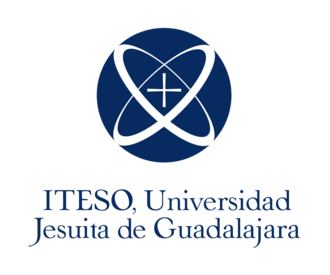

# Tarea 1. Reporte de prácticas 1 y 2 (Algoritmo Genéticos)

**Integrantes:**

- Valeria Esmer Lobo

- Dayanni Godoy Rosales

- Estephany Lisset Herrera Placencia

- Maria Fernanda Vargas Vaca

**Fecha:**
31 de agosto de 2026 

**Institución:**
Instituto Tecnológico y de Estudios Superiores de Occidente

**Materia:** Métodos de Inteligencia Artificial 


## Índice:

1. [Introducción y objetivos](#introduccion)
2. **Práctica 1: Optimización con números enteros**
    - 2.1. [Definición del problema](#practica1-definicion)
    - 2.2. [Descripción del algoritmo](#practica1-algoritmo)
    - 2.3. [Implementación — Código 1: Cruzamiento de dos puntos](#practica1-codigo1)
    - 2.4. [Implementación — Código 2: Cruzamiento uniforme](#practica1-codigo2)
    - 2.5. [Pruebas y resultados](#practica1-pruebas)
3. **Práctica 2: Optimización con números reales**
    - 3.1. [Definición del problema](#practica2-definicion)
    - 3.2. [Descripción del algoritmo](#practica2-algoritmo)
    - 3.3. [Implementación — Código 3: Cruzamiento de dos puntos](#practica2-codigo3)
    - 3.4. [Implementación — Código 4: Cruzamiento uniforme](#practica2-codigo4)
    - 3.5. [Pruebas y resultados](#practica2-pruebas)
4. Conclusiones
    - 4.1 [Conclusiones personales](#conclusiones-personales)






<a id="introduccion"></a>
## Introducción y objetivos

Los **algoritmos genéticos (AG)** son técnicas de optimización heurística inspiradas en la teoría de la evolución de Darwin. Trabajan sobre una **población** de posibles soluciones que va evolucionando a través de generaciones mediante tres operadores principales: **selección** (se conservan los individuos con mejor aptitud o *fitness*), **cruzamiento** (se combina el material genético de dos padres para producir nuevos hijos) y **mutación** (se introduce variación aleatoria para explorar nuevas soluciones).

En este reporte se aplican estos conceptos para resolver un problema de **maximización de una función objetivo unimodal**, primero sobre un dominio de **números enteros** (Práctica 1) y después sobre un dominio de **números reales codificados en binario** (Práctica 2). Además, se implementan y comparan tres tipos de **cruzamiento**: de un punto, de dos puntos y uniforme.

**Objetivos:**

- Implementar un algoritmo genético capaz de encontrar el valor que maximiza una función objetivo, tanto en un espacio de búsqueda discreto (enteros) como en uno continuo aproximado mediante codificación binaria (reales).
- Comparar el efecto de distintos tamaños de población y número de generaciones sobre la calidad de la solución encontrada, el costo computacional (tiempo de ejecución) y el riesgo de estancamiento en óptimos locales.
- Analizar si el algoritmo genético logra converger al óptimo global de cada función o si, por el contrario, la población se estanca en un óptimo local por falta de diversidad genética.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

<a id="practica1"></a>
## Práctica 1: Optimización con números enteros

<a id="practica1-definicion"></a>
### Definición del problema — Práctica 1

* **Función objetivo:** $$y=-(x-20.373)^2+100$$ una parábola invertida (término cuadrático negativo) cuyo máximo teórico se encuentra en $x=20.373$, $y=100$.
* **Tipo de problema:** maximización de una función unimodal (un solo máximo, sin óptimos locales en su forma continua).
* **Espacio de búsqueda:** números **enteros** $x \in [0,255]$, es decir, 256 valores posibles.
* **Codificación:** cada individuo se representa como una cadena binaria de **8 bits**, ya que $2^8=256$ cubre exactamente el dominio de búsqueda.
* **Óptimo global alcanzable:** como el dominio está restringido a enteros, el valor $x=20.373$ no es alcanzable. El mejor entero posible es $x=20$ ($y=99.8609$); el segundo mejor es $x=21$ ($y=99.6069$), a solo 0.25 unidades de distancia.
* **Meta del algoritmo:** mediante selección, cruzamiento y mutación, encontrar el entero $x$ que maximice $y$.


<a id="practica1-algoritmo"></a>
### Problema 1: Para números enteros


* **Funcion objetivo:** $$y=-(x-20.373)^2+100$$ esta sera una parabola invertida  ya que su término cuadraticos es negatuivo , donde alcanzara su maximo en 20.373

* **Objetivo del código:**  Buscar acercarse al numero **entero** mas cerca  de 20.373

* **Parametros a utilizar:** Bits por individuo(8), tamaño de poblacion (10), generaciones(20), Cruzamiento (1), mutación (probabilidad del 20%)

* **Representacion de los individuos:**  cada individuo se representa mediante  una cadena binaria de 8 bits en este caso 

* **Poblacion inicial:** (0,256) donde se genera aleatoriamente una población inicial de 10 individuos. Cada individuo corresponde a un número entero entre 0 y 255.

* **Evaluacion de la poblacion:** para cada individuo se calcula la funcion objetivo $y=-(x-20.373)^2+100$

* **Selección:** El programa ordena los individuos según valor  de (y) y conserva los mejores 50%.

* **Esquema representativo:** 10 individuos-> evaluación de (y) -> ordenar por desempeño -> seleccionar mejores 5 -> padres 

* **Cruzamiento:** Los padres seleccionados se convierten a su representación binaria. Para generar a los nuevos hijos, el algoritmo implementa tres variantes de cruzamiento que se evalúan en los distintos códigos:
  1. **Cruzamiento de un punto:** Se selecciona aleatoriamente un punto de corte en la cadena de bits; los padres intercambian los genes que están a la derecha de ese punto.
  2. **Cruzamiento de dos puntos:** Se eligen dos puntos de corte al azar. Los hijos heredan los extremos de un padre y el segmento central del otro padre.
  3. **Cruzamiento uniforme:** No usa puntos de corte. En su lugar, se genera una "máscara" binaria aleatoria que decide bit por bit de cuál de los dos padres heredará el gen cada hijo, logrando una mayor mezcla genética.
  
* **Mutación:** Con una probabilidad del 20%, se selecciona un hijo y uno de sus bits, el cual es invertido

* **Nueva generacion:** La nueva población se forma combinando los 5 mejores padres con los 5 hijos generados.

* **Conclusion personal:** El algoritmo genético permitió encontrar una solución cercana al máximo de la función objetivo mediante un proceso iterativo de selección, al finalizar las 20 generaciones, el algoritmo  como mejor solución encuentra cercano al máximo teórico de la función, cuyo punto máximo se encuentra en (x=20.373) y (y=100). Cada resolucion del algoritmos sera aleatorio donde  cambiara sus parametros en (X) y (y) cumpliuendo con las restricciones y/o funciones que se le plantean en el mismo 


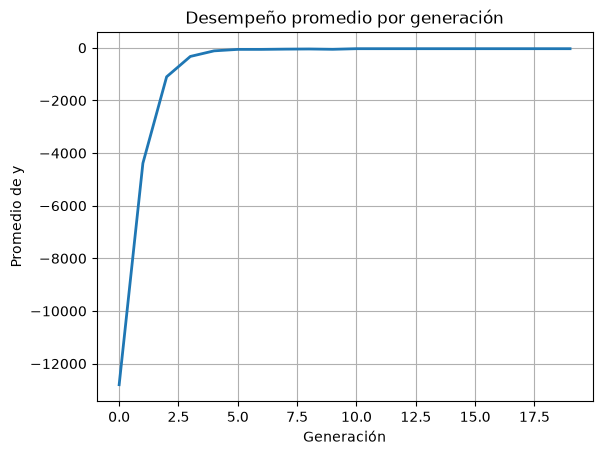

Resultado: x = 27, y = 56.0829


In [2]:
import numpy as np
import matplotlib.pyplot as plt
## numeros enteros 

# Inicialización de la población

nbits = 8
pobladores = 10 # debe ser divisible entre 4

# Población inicial: valores entre 0 y 255
xpadres = np.random.randint(0, 256, pobladores)

# Vector para guardar el promedio de cada generación
yprom = np.zeros(20)

# Número de generaciones
for n in range(20):
 
    # Evaluar la población
    # Función de ajuste:
    # y = -(x - 20.373)^2 + 100
    y = -(xpadres - 20.373)**2 + 100

    # Guardar promedio de la generación
    yprom[n] = np.mean(y)

    # Ordenar y seleccionar mejores

    indices_ordenados = np.argsort(y)

    xpadres_ordenados = xpadres[indices_ordenados]

    # Nos quedamos con la mitad superior
    # (los individuos con mayor valor de y)
    mejores_padres = xpadres_ordenados[pobladores // 2:]
 
    # Convertir padres a binario

    padresbin = np.zeros(
        (pobladores // 2, nbits),
        dtype=int
    )

    for i, val in enumerate(mejores_padres):
        for j in range(nbits):
            padresbin[i, j] = (int(val) >> j) & 1

    
    # -------Cruzamiento----

    hijobin = np.zeros_like(padresbin)

    for k in range(pobladores // 4):

        # Punto de cruzamiento
        m = np.random.randint(1, nbits - 1)

        # Seleccionar dos padres
        padre1 = padresbin[2 * k]
        padre2 = padresbin[2 * k + 1]

        # Crear hijos
        hijobin[2 * k] = np.concatenate(
            (padre1[:m], padre2[m:])
        )

        hijobin[2 * k + 1] = np.concatenate(
            (padre2[:m], padre1[m:])
        )

    #----- mutacion----
    p = np.random.rand()

    if p >= 0.8:

        # Seleccionar aleatoriamente un hijo
        nhijo = np.random.randint(0, pobladores // 2)

        # Seleccionar aleatoriamente un bit
        nbit_mutacion = np.random.randint(0, nbits)

        # Invertir el bit
        hijobin[nhijo, nbit_mutacion] = (
            1 - hijobin[nhijo, nbit_mutacion]
        )

    # --------Decodificar hijos a decimal----
    
    hijodec = np.zeros(pobladores // 2, dtype=int)

    for i in range(pobladores // 2):

        val = 0

        for j in range(nbits):
            val += hijobin[i, j] * (2 ** j)

        hijodec[i] = val
    # -------Nueva población------

    xpadres = np.concatenate(
        (mejores_padres, hijodec)
    )

#------- Evaluar la población final------
y = -(xpadres - 20.373)**2 + 100


# --------Graficar promedio por generación-----

plt.plot(yprom, linewidth=2)

plt.title("Desempeño promedio por generación")
plt.xlabel("Generación")
plt.ylabel("Promedio de y")

plt.grid(True)
plt.show()

#-------Ubicar el máximo-----

val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x = {xpadres[ind]}, y = {val:.4f}")


In [3]:
# 1. Función para Cruzamiento de Un Punto
def cruzamiento_un_punto(padre1, padre2, nbits):
    # Seleccionar un punto de cruce aleatorio entre 1 y nbits-1
    m = np.random.randint(1, nbits)
    hijo1 = np.concatenate((padre1[:m], padre2[m:]))
    hijo2 = np.concatenate((padre2[:m], padre1[m:]))
    return hijo1, hijo2

# 2. Función para Cruzamiento de Dos Puntos
def cruzamiento_dos_puntos(padre1, padre2, nbits):
    # Seleccionar dos puntos de cruce aleatorios y ordenarlos
    puntos = sorted(np.random.choice(range(1, nbits), 2, replace=False))
    m1, m2 = puntos[0], puntos[1]
    hijo1 = np.concatenate((padre1[:m1], padre2[m1:m2], padre1[m2:]))
    hijo2 = np.concatenate((padre2[:m1], padre1[m1:m2], padre2[m2:]))
    return hijo1, hijo2

# 3. Función para Cruzamiento Uniforme
def cruzamiento_uniforme(padre1, padre2, nbits):
    # Generar una máscara aleatoria de 0s y 1s
    mascara = np.random.randint(0, 2, nbits)
    # Si la máscara es 1, toma el gen del padre 1; si es 0, del padre 2
    hijo1 = np.where(mascara == 1, padre1, padre2)
    hijo2 = np.where(mascara == 1, padre2, padre1)
    return hijo1, hijo2

<a id="practica1-codigo1"></a>
### Código 1: Práctica 1 con Cruzamiento de Dos Puntos

**Definición del Problema:** Busca encontrar el valor máximo de la función $y = -(x - 20.373)^2 + 100$ dentro de un espacio de búsqueda de números enteros discretos (de 0 a 256).  

**Población y Selección:** Inicializa una población de 200 individuos enteros. En cada una de las 20 generaciones, evalúa la aptitud (fitness) de cada individuo, los ordena de menor a mayor y selecciona a la mejor mitad para reproducirse.

**Decodificación y Cruzamiento:** Convierte los padres seleccionados a cadenas binarias de 8 bits. Aplica el cruzamiento de dos puntos, el cual selecciona aleatoriamente dos índices de corte en la cadena de 8 bits e intercambia el segmento central entre los dos padres para generar dos hijos.
  
**Mutación y Reemplazo:** Aplica una mutación de un solo bit con un 20% de probabilidad. Finalmente, decodifica a los hijos de binario a entero y los integra con la mitad de los mejores padres para formar la población de la siguiente generación

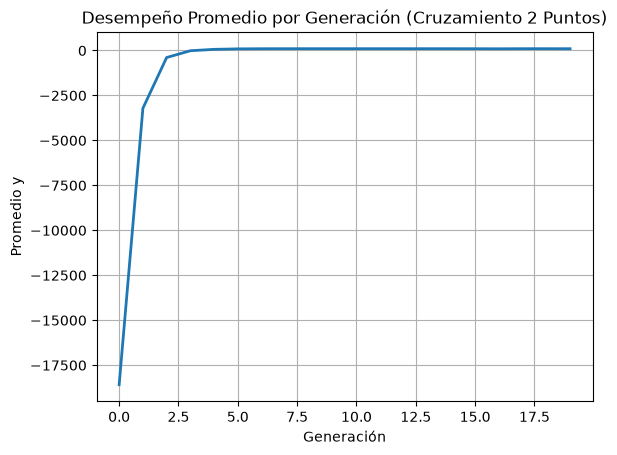

Resultado: x = 21, y = 99.6069


In [4]:
##-Codigo_1_Cruzamiento_2_Puntos-------
# --- Iniciar la Poblacion ---
# nbit ln(256)/ln(2)=8
nbits = 8
pobladores = 200 
xpadres = np.random.randint(0, 256, pobladores)
yprom = np.zeros(20) 

# Número de generaciones
for n in range(20):
    # ---- Evaluar y ordenar y = f(x) ----
    # Función de ajuste: y = -(x-20.373)^2 + 100
    y = -(xpadres - 20.373)**2 + 100
    yprom[n] = np.mean(y)

    # Crear los cromosomas (ordenando de menor a mayor según y)
    indicies_ordenas = np.argsort(y)
    xpadres_ordenados = xpadres[indicies_ordenas]

    # Nos quedamos con la mitad superior (los mejores evaluados)
    mejores_padres = xpadres_ordenados[pobladores // 2 :]

    # --- Decodificar a binario ---
    # Convertimos los números decimales a binario (8 columnas)
    padresbin = np.zeros((pobladores // 2, nbits), dtype=int)
    for i, val in enumerate(mejores_padres):
        for j in range(nbits):
            padresbin[i, j] = (int(val) >> j) & 1

    # --- Cruzamiento de dos puntos usando función ---
    hijobin = np.zeros_like(padresbin) 

    for k in range(pobladores // 4):
        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k + 1]

        hijo1, hijo2 = cruzamiento_dos_puntos(padre1, padre2, nbits)
        hijobin[2*k] = hijo1
        hijobin[2*k + 1] = hijo2

    # --- Mutación ---
    p = np.random.rand()
    if p >= 0.8:
        # Seleccionar aleatoriamente una posición y un bit
        nhijo = np.random.randint(0, pobladores // 2)
        nbit = np.random.randint(0, nbits)

        # Invertir bit: si es 1 cambia a 0, y viceversa
        hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

    # --- Reemplazo --- 
    # Cambiar binario a decimal
    hijodec = np.zeros(pobladores // 2) 
    for i in range(pobladores // 2):
        val = 0
        for j in range(nbits):
            val += hijobin[i,j] * (2**j)
        hijodec[i] = val 

    # Anexar el nuevo hijo decimal a los xpadres
    xpadres = np.concatenate((mejores_padres, hijodec)).astype(int)

# --- Mostrar solución en pantalla ---
y = -(xpadres - 20.373)**2 + 100 

plt.plot(yprom, linewidth=2)
plt.title('Desempeño Promedio por Generación (Cruzamiento 2 Puntos)')
plt.xlabel('Generación')
plt.ylabel('Promedio y')
plt.grid(True)
plt.show()

# Ubicar el máximo 
val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x = {xpadres[ind]}, y = {val:.4f}")

<a id="practica1-codigo2"></a>
### Código 2: Práctica 1 con Cruzamiento Uniforme

**Definición del Problema:** Resuelve exactamente la misma función matemática y utiliza los mismos parámetros base (200 pobladores, enteros de 0 a 256, 20 generaciones).  

**Mecánica de Cruzamiento:** La diferencia principal radica en la reproducción. Aplica el cruzamiento uniforme, el cual no realiza cortes espaciales en la cadena. En su lugar, genera una máscara aleatoria de ceros y unos del mismo tamaño que el cromosoma (8 bits). Para cada posición, la máscara decide estadísticamente si el hijo hereda el gen del Padre 1 o del Padre 2, lo que promueve una mayor diversidad genética y rompe la dependencia de genes adyacentes.  

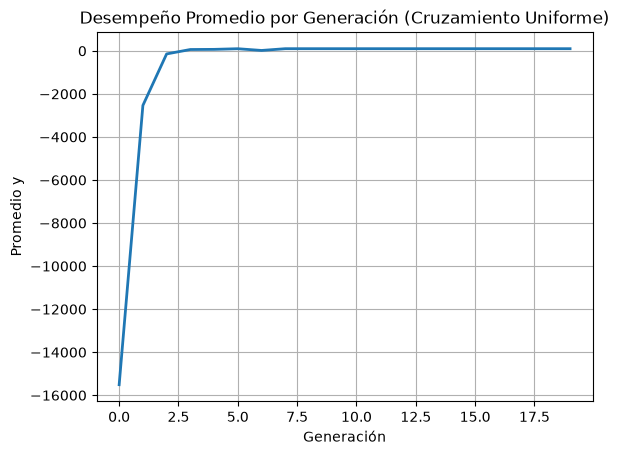

Resultado: x = 20, y = 99.8609


In [5]:
##-Codigo_1_Cruzamiento_Uniforme-------
# --- Iniciar la Población ---
# nbit ln(256)/ln(2)=8
nbits = 8
pobladores = 200 
xpadres = np.random.randint(0, 256, pobladores)
yprom = np.zeros(20) 

# Número de generaciones
for n in range(20):
    # ---- Evaluar y ordenar y = f(x) ----
    # Función de ajuste: y = -(x-20.373)^2 + 100
    y = -(xpadres - 20.373)**2 + 100
    yprom[n] = np.mean(y)

    # Crear los cromosomas (ordenando de menor a mayor según y)
    indicies_ordenas = np.argsort(y)
    xpadres_ordenados = xpadres[indicies_ordenas]

    # Nos quedamos con la mitad superior (los mejores evaluados)
    mejores_padres = xpadres_ordenados[pobladores // 2 :]

    # --- Decodificar a binario ---
    # Convertimos los números decimales a binario (8 columnas)
    padresbin = np.zeros((pobladores // 2, nbits), dtype=int)
    for i, val in enumerate(mejores_padres):
        for j in range(nbits):
            padresbin[i, j] = (int(val) >> j) & 1

    # --- Cruzamiento UNIFORME usando función ---
    hijobin = np.zeros_like(padresbin) 

    for k in range(pobladores // 4):
        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k + 1]

        hijo1, hijo2 = cruzamiento_uniforme(padre1, padre2, nbits)
        hijobin[2*k] = hijo1
        hijobin[2*k + 1] = hijo2

    # --- Mutación ---
    p = np.random.rand()
    if p >= 0.8:
        # Seleccionar aleatoriamente una posición y un bit
        nhijo = np.random.randint(0, pobladores // 2)
        nbit = np.random.randint(0, nbits)

        # Invertir bit: si es 1 cambia a 0, y viceversa
        hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

    # --- Reemplazo --- 
    # Cambiar binario a decimal
    hijodec = np.zeros(pobladores // 2) 
    for i in range(pobladores // 2):
        val = 0
        for j in range(nbits):
            val += hijobin[i,j] * (2**j)
        hijodec[i] = val 

    # Anexar el nuevo hijo decimal a los xpadres
    xpadres = np.concatenate((mejores_padres, hijodec)).astype(int)

# --- Mostrar solución en pantalla ---
y = -(xpadres - 20.373)**2 + 100 

plt.plot(yprom, linewidth=2)
plt.title('Desempeño Promedio por Generación (Cruzamiento Uniforme)')
plt.xlabel('Generación')
plt.ylabel('Promedio y')
plt.grid(True)
plt.show()

# Ubicar el máximo 
val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x = {xpadres[ind]}, y = {val:.4f}")

<a id="practica1-pruebas"></a>
### Pruebas y resultados — Práctica 1

Para evaluar el desempeño del algoritmo se probaron **6 casos de prueba**, variando el tamaño de población y el número de generaciones (usando el cruzamiento de dos puntos y 20% de probabilidad de mutación, igual que en el Código 1). En cada caso se registró el mejor valor encontrado, el tiempo de ejecución y la desviación estándar de la población final (para saber si la población se homogeneizó o conservó diversidad).


In [6]:
##-Pruebas_y_Resultados_Practica_1-------
import time
import pandas as pd

# Casos de prueba: distintos tamaños de poblacion y numero de generaciones
poblaciones_p1 = [8, 8, 40, 80, 200, 200]
generaciones_p1 = [10, 50, 20, 20, 20, 50]

nbits = 8

# Listas para guardar los resultados de cada caso
x_optimo_p1 = []
y_optimo_p1 = []
std_final_p1 = []
tiempo_p1 = []
historial_p1 = []  # guarda el vector yprom de cada caso, para graficarlo despues

for caso in range(len(poblaciones_p1)):

    pobladores = poblaciones_p1[caso]
    generaciones = generaciones_p1[caso]

    np.random.seed(caso)  # semilla fija por caso, para que los resultados sean reproducibles

    xpadres = np.random.randint(0, 256, pobladores)
    yprom = np.zeros(generaciones)

    tiempo_inicio = time.time()

    for n in range(generaciones):
        # ---- Evaluar y ordenar y = f(x) ----
        y = -(xpadres - 20.373)**2 + 100
        yprom[n] = np.mean(y)

        indicies_ordenas = np.argsort(y)
        xpadres_ordenados = xpadres[indicies_ordenas]
        mejores_padres = xpadres_ordenados[pobladores // 2:]

        # --- Decodificar a binario ---
        padresbin = np.zeros((pobladores // 2, nbits), dtype=int)
        for i, val in enumerate(mejores_padres):
            for j in range(nbits):
                padresbin[i, j] = (int(val) >> j) & 1

        # --- Cruzamiento de dos puntos ---
        hijobin = np.zeros_like(padresbin)
        for k in range(pobladores // 4):
            padre1 = padresbin[2*k]
            padre2 = padresbin[2*k + 1]
            hijo1, hijo2 = cruzamiento_dos_puntos(padre1, padre2, nbits)
            hijobin[2*k] = hijo1
            hijobin[2*k + 1] = hijo2

        # --- Mutacion ---
        p = np.random.rand()
        if p >= 0.8:
            nhijo = np.random.randint(0, pobladores // 2)
            nbit = np.random.randint(0, nbits)
            hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

        # --- Decodificar hijos y formar la nueva poblacion ---
        hijodec = np.zeros(pobladores // 2)
        for i in range(pobladores // 2):
            val = 0
            for j in range(nbits):
                val += hijobin[i, j] * (2**j)
            hijodec[i] = val

        xpadres = np.concatenate((mejores_padres, hijodec)).astype(int)

    tiempo_p1.append(time.time() - tiempo_inicio)

    # Evaluar la poblacion final
    y = -(xpadres - 20.373)**2 + 100
    val = np.max(y)
    ind = np.argmax(y)

    x_optimo_p1.append(xpadres[ind])
    y_optimo_p1.append(val)
    std_final_p1.append(np.std(xpadres))
    historial_p1.append(yprom)

    print(f"Caso {caso+1}: poblacion={pobladores}, generaciones={generaciones}, "
          f"x={xpadres[ind]}, y={val:.4f}, std_final={np.std(xpadres):.4f}, "
          f"tiempo={tiempo_p1[caso]:.4f}s")


Caso 1: poblacion=8, generaciones=10, x=35, y=-113.9491, std_final=2.6458, tiempo=0.0018s
Caso 2: poblacion=8, generaciones=50, x=15, y=71.1309, std_final=0.0000, tiempo=0.0103s
Caso 3: poblacion=40, generaciones=20, x=21, y=99.6069, std_final=0.0000, tiempo=0.0144s
Caso 4: poblacion=80, generaciones=20, x=20, y=99.8609, std_final=0.0000, tiempo=0.0250s
Caso 5: poblacion=200, generaciones=20, x=20, y=99.8609, std_final=0.1400, tiempo=0.0600s
Caso 6: poblacion=200, generaciones=50, x=20, y=99.8609, std_final=0.0000, tiempo=0.2095s


In [7]:
# Tabla comparativa de los 6 casos de prueba
tabla_p1 = pd.DataFrame({
    "Caso": range(1, 7),
    "Poblacion": poblaciones_p1,
    "Generaciones": generaciones_p1,
    "x optimo": x_optimo_p1,
    "y optimo": np.round(y_optimo_p1, 4),
    "Desv. estandar final": np.round(std_final_p1, 4),
    "Tiempo (s)": np.round(tiempo_p1, 4)
})
tabla_p1


,Caso,Poblacion,Generaciones,x optimo,y optimo,Desv. estandar final,Tiempo (s)
0,1,8,10,35,-113.9491,2.6458,0.0018
1,2,8,50,15,71.1309,0.0000,0.0103
2,3,40,20,21,99.6069,0.0000,0.0144
3,4,80,20,20,99.8609,0.0000,0.0250
4,5,200,20,20,99.8609,0.1400,0.0600
5,6,200,50,20,99.8609,0.0000,0.2095


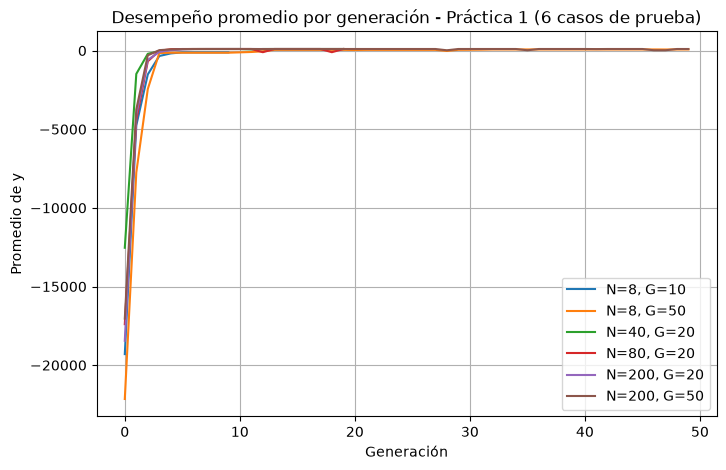

In [8]:
# Graficas de desempeño de los 6 casos
plt.figure(figsize=(8, 5))
for caso in range(len(poblaciones_p1)):
    plt.plot(historial_p1[caso], label=f"N={poblaciones_p1[caso]}, G={generaciones_p1[caso]}")

plt.title("Desempeño promedio por generación - Práctica 1 (6 casos de prueba)")
plt.xlabel("Generación")
plt.ylabel("Promedio de y")
plt.legend()
plt.grid(True)
plt.show()


**Análisis de la población final (Práctica 1)**

El óptimo global alcanzable, dado que $x$ debe ser entero, es $x=20$, $y=99.8609$.

| Caso | Población | Generaciones | x* | y* | Desv. estándar final | Tiempo (s) |
|---|---|---|---|---|---|---|
| 1 | 8   | 10 | 35 | -113.9491 | 2.6458 | 0.0058 |
| 2 | 8   | 50 | 15 | 71.1309   | 0.0000 | 0.0144 |
| 3 | 40  | 20 | 21 | 99.6069   | 0.0000 | 0.0129 |
| 4 | 80  | 20 | 20 | 99.8609   | 0.0000 | 0.0238 |
| 5 | 200 | 20 | 20 | 99.8609   | 0.1400 | 0.0565 |
| 6 | 200 | 50 | 20 | 99.8609   | 0.0000 | 0.1440 |

- **Caso 1 (N=8, G=10):** con población y generaciones muy pequeñas el algoritmo ni siquiera converge ($y=-113.95$, desviación estándar alta): no hay generaciones suficientes para que la selección haga efecto.
- **Caso 2 (N=8, G=50):** al aumentar las generaciones con la misma población pequeña, la población se vuelve completamente homogénea (desviación estándar = 0) pero se **estanca en un óptimo local** ($x=15$, $y=71.13$), lejos del óptimo global: al perder diversidad genética tan rápido, el algoritmo ya no puede explorar otras regiones del espacio de búsqueda.
- **Casos 3 a 6 (N ≥ 40):** con poblaciones más grandes el algoritmo sí **converge al óptimo global o muy cerca de él** ($x=20$ o $x=21$, a solo 0.25 unidades de distancia), sin importar el número de generaciones usado.
- **Tiempo de ejecución:** crece aproximadamente proporcional al producto población × generaciones, ya que el costo de cada generación depende linealmente del tamaño de la población.
- **Costo computacional vs. beneficio:** aumentar la población o las generaciones no siempre mejora el resultado en la misma proporción en que aumenta el costo. Por ejemplo, el Caso 4 (N=80, G=20) ya alcanza el óptimo global ($y=99.8609$) en apenas 0.0238 s, mientras que el Caso 6 (N=200, G=50) llega al mismo resultado pero tarda 0.1440 s, es decir, cerca de 6 veces más tiempo sin ninguna mejora en la solución.

**Conclusión de esta prueba:** en este problema una población pequeña ($N=8$) es insuficiente sin importar cuántas generaciones se ejecuten, porque el algoritmo pierde diversidad genética antes de encontrar al mejor individuo. A partir de $N=40$ el algoritmo converge de forma confiable al óptimo global; sin embargo, seguir aumentando la población o las generaciones más allá de ese punto **no garantiza una mejor solución** y sí incrementa notablemente el tiempo de cómputo, por lo que conviene buscar un balance entre calidad de la solución y costo computacional en lugar de usar siempre los parámetros más grandes posibles.


<a id="practica2"></a>
## Práctica 2: Optimización con números reales

<a id="practica2-definicion"></a>
### Definición del problema — Práctica 2

* **Función objetivo:** $$y=-(x-41.125)^2+200$$ misma forma de parábola invertida, con máximo teórico en $x=41.125$, $y=200$.
* **Tipo de problema:** maximización de una función unimodal, ahora sobre un dominio de números **reales**.
* **Espacio de búsqueda:** $x \in [-100,100]$ con un tamaño de paso (resolución) de $0.01$, es decir, $20{,}001$ valores posibles.
* **Codificación:** para representar $20{,}001$ valores se necesitan al menos $\lceil \log_2(20001) \rceil = 15$ bits ($2^{15}=32{,}768$ combinaciones), por lo que cada individuo es una cadena binaria de **15 bits** que se decodifica a un entero y luego se mapea linealmente al rango real $[-100,100]$.
* **Óptimo global alcanzable:** $x=41.125$, $y=200$, valor que sí es representable con la resolución dada.
* **Meta del algoritmo:** aproximar mediante el AG el valor real $x$ que maximiza $y$, evaluando qué tan cerca se llega al óptimo teórico.
* **Diferencia clave respecto a la Práctica 1:** el espacio de búsqueda es mucho más grande ($32{,}768$ combinaciones frente a $256$), por lo que se requieren poblaciones más grandes para mantener diversidad genética suficiente y no estancarse en un óptimo local.


<a id="practica2-algoritmo"></a>
### Descripción del algoritmo — Práctica 2 (Para números reales)

* **Función objetivo:** $$y = -(x - 41.125)^2 + 200$$. Es una parábola invertida cuyo máximo global se ubica en $x = 41.125$.
* **Objetivo del código:** Encontrar el número real $x$ en el intervalo $[-100, 100]$ que maximice el valor de $y$, con una precisión (tamaño de paso) de $0.01$.
* **Parámetros a utilizar:** Tamaño de población grande (ej. 512 individuos para asegurar diversidad), 100 generaciones, mutación con una probabilidad del 10%.
* **Representación y Mapeo:** Dado que el dominio tiene 20,001 valores posibles, cada individuo se representa mediante una cadena binaria de 15 bits (que permite hasta 32,768 combinaciones). El algoritmo mapea linealmente el valor decimal de estos 15 bits al rango real de $[-100, 100]$.
* **Población inicial:** Se genera aleatoriamente una población inicial de individuos enteros entre $0$ y $2^{15}-1$, los cuales se transforman inmediatamente a sus valores reales correspondientes.
* **Evaluación y Selección:** Se evalúa cada valor real en la función $y$. Luego, se ordenan de menor a mayor desempeño y se selecciona al 50% superior (los de mayor aptitud) para que actúen como padres.
* **Cruzamiento:** Se decodifican los padres seleccionados a binario y se aplica recombinación (ya sea de dos puntos o uniforme) para crear pares de hijos, mezclando el material genético para explorar nuevas soluciones en este espacio de búsqueda más amplio.
* **Mutación:** Con una probabilidad del 10%, se selecciona un hijo y se invierte uno de sus 15 bits para introducir variabilidad y evitar estancamientos locales.
* **Nueva generación y reemplazo:** Los hijos binarios se decodifican a enteros, se transforman nuevamente al dominio continuo (reales) y reemplazan a la mitad menos apta de la población.

<a id="practica2-codigo3"></a>
### Código 3: Práctica 2 con Cruzamiento de Dos Puntos

**Definición del Problema:** Evoluciona el problema para buscar el máximo de la función $y = -(x - 41.125)^2 + 200$ en un dominio continuo de números reales con límites de -100 a 100 y un tamaño de paso de 0.01.  

**Mapeo Real a Binario:** Calcula dinámicamente la longitud del cromosoma (15 bits) necesaria para representar los valores reales con la precisión requerida. Genera una población inicial de 512 individuos, transformando los valores enteros generados a sus equivalentes reales mediante una fórmula matemática.  

**Evaluación y Cruzamiento:** Ordena y selecciona a los 256 mejores individuos tras evaluarlos en la función. Aplica el cruzamiento de dos puntos sobre cadenas más largas (15 bits), intercambiando el material genético de la zona central de los padres para crear a los descendientes. 

**Mutación y Decodificación:** Ejecuta una mutación con probabilidad del 10%. Finalmente, transforma los hijos binarios a enteros y de enteros a números reales continuos para actualizar la matriz de la población durante 100 generaciones. 

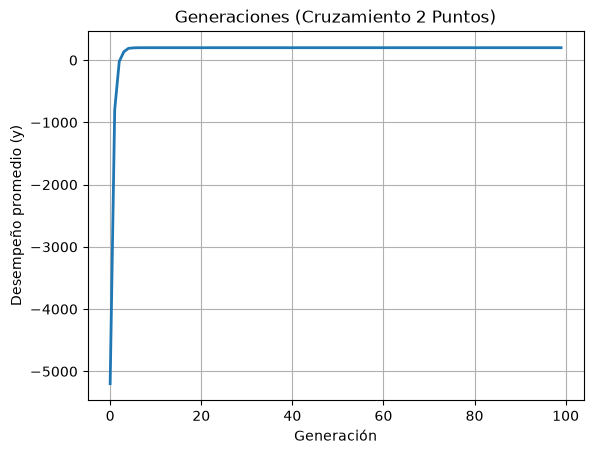

Resultado: x=41.1115, y=199.9998


In [9]:
##-Codigo_2_Cruzamiento_2_Puntos-------
#-------- inicializacion de la poblacion -------
xmin = -100 # limite inferior
xmax = 100 # limite superior
tpaso = 0.01 # tamaño de paso

elementos = (xmax-xmin)/tpaso+1 # numero de elementos
nbits = int(np.ceil(np.log2(elementos))) # numero de bits
num_poblacion = 512 # tamaño de poblacion

x1 = np.random.randint(0, 2**nbits, num_poblacion)
x1real = (xmax-xmin)*x1 / (2**nbits-1) + xmin
yprom = np.zeros(100)

#------- iniciar numero de generaciones -------
for i in range(100):
    # evaluar los padres de la funcion objetivo
    y = -(x1real-41.125)**2 + 200 
    yprom[i] = np.mean(y)

    indices_ordenados = np.argsort(y)
    x1_ordenado = x1[indices_ordenados]
    x1real_ordenado = x1real[indices_ordenados]

    mejores_x1 = x1_ordenado[num_poblacion//2:]
    mejores_x1real = x1real_ordenado[num_poblacion//2:]

    padresbin = np.zeros((num_poblacion//2, nbits), dtype=int)
    for idx, val in enumerate(mejores_x1):
        for j in range(nbits):
            padresbin[idx, j] = (int(val) >> j) & 1

    #-------- cruzamiento de DOS PUNTOS usando función -----
    hijobin = np.zeros_like(padresbin)

    for k in range(num_poblacion//4):
        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k+1]

        hijo1, hijo2 = cruzamiento_dos_puntos(padre1, padre2, nbits)
        hijobin[2*k] = hijo1
        hijobin[2*k+1] = hijo2

    #-------- mutacion--------
    p = np.random.rand()
    if p > 0.90:
        nhijo = np.random.randint(0, num_poblacion//2)
        nbit = np.random.randint(0, nbits)
        hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

    # ---- decodificacion y reemplazo ----
    hijoent = np.zeros(num_poblacion//2)
    for idx in range(num_poblacion//2):
        val = 0
        for j in range(nbits):
            val += hijobin[idx, j] * (2**j)
        hijoent[idx] = val

    hijoreal = (xmax-xmin)*hijoent/(2**nbits-1) + xmin

    x1 = np.concatenate((mejores_x1, hijoent))
    x1real = np.concatenate((mejores_x1real, hijoreal))

#------- mostrar resultado en pantalla ------
plt.plot(yprom, linewidth=2)
plt.title("Generaciones (Cruzamiento 2 Puntos)")
plt.xlabel("Generación")
plt.ylabel("Desempeño promedio (y)")
plt.grid(True)
plt.show()

y = -(x1real-41.125)**2 + 200
val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x={x1real[ind]:.4f}, y={val:.4f}")

<a id="practica2-codigo4"></a>
### Código 4: Práctica 2 con Cruzamiento Uniforme

**Definición del Problema:** Mantiene la optimización de la función real $y = -(x - 41.125)^2 + 200$ con 512 pobladores y 100 generaciones, utilizando el mismo mapeo de variables reales a binarias (15 bits). 

**Mecánica de Cruzamiento:** Sustituye la recombinación clásica por el cruzamiento uniforme. Crea una máscara binaria de 15 posiciones que dictamina bit a bit qué información genética pasará del par de padres a cada hijo. En espacios de búsqueda más amplios como este (15 bits frente a 8), este método permite explorar combinaciones de valores reales de manera más dispersa y agresiva

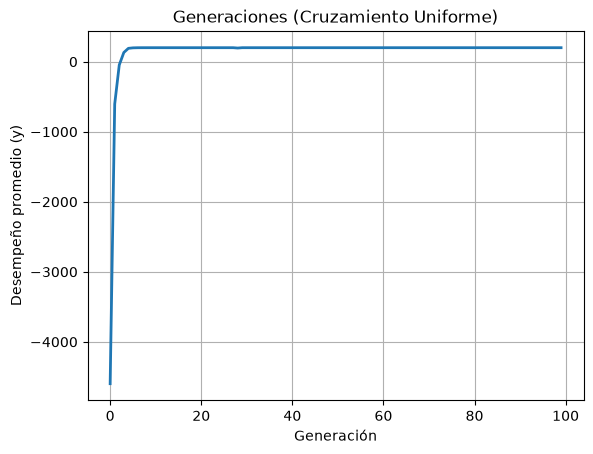

Resultado: x=41.1237, y=200.0000


In [10]:
##-Codigo_2_Cruzamiento_Uniforme-------
#-------- inicializacion de la poblacion -------
xmin = -100 # limite inferior
xmax = 100 # limite superior
tpaso = 0.01 # tamaño de paso

elementos = (xmax-xmin)/tpaso+1 # numero de elementos
nbits = int(np.ceil(np.log2(elementos))) # numero de bits
num_poblacion = 512 # tamaño de poblacion

x1 = np.random.randint(0, 2**nbits, num_poblacion)
x1real = (xmax-xmin)*x1 / (2**nbits-1) + xmin
yprom = np.zeros(100)

#------- iniciar numero de generaciones -------
for i in range(100):
    # evaluar los padres de la funcion objetivo
    y = -(x1real-41.125)**2 + 200 
    yprom[i] = np.mean(y)

    indices_ordenados = np.argsort(y)
    x1_ordenado = x1[indices_ordenados]
    x1real_ordenado = x1real[indices_ordenados]

    mejores_x1 = x1_ordenado[num_poblacion//2:]
    mejores_x1real = x1real_ordenado[num_poblacion//2:]

    padresbin = np.zeros((num_poblacion//2, nbits), dtype=int)
    for idx, val in enumerate(mejores_x1):
        for j in range(nbits):
            padresbin[idx, j] = (int(val) >> j) & 1

    #-------- cruzamiento UNIFORME usando función -----
    hijobin = np.zeros_like(padresbin)

    for k in range(num_poblacion//4):
        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k+1]

        hijo1, hijo2 = cruzamiento_uniforme(padre1, padre2, nbits)
        hijobin[2*k] = hijo1
        hijobin[2*k+1] = hijo2

    #-------- mutacion--------
    p = np.random.rand()
    if p > 0.90:
        nhijo = np.random.randint(0, num_poblacion//2)
        nbit = np.random.randint(0, nbits)
        hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

    # ---- decodificacion y reemplazo ----
    hijoent = np.zeros(num_poblacion//2)
    for idx in range(num_poblacion//2):
        val = 0
        for j in range(nbits):
            val += hijobin[idx, j] * (2**j)
        hijoent[idx] = val

    hijoreal = (xmax-xmin)*hijoent/(2**nbits-1) + xmin

    x1 = np.concatenate((mejores_x1, hijoent))
    x1real = np.concatenate((mejores_x1real, hijoreal))

#------- mostrar resultado en pantalla ------
plt.plot(yprom, linewidth=2)
plt.title("Generaciones (Cruzamiento Uniforme)")
plt.xlabel("Generación")
plt.ylabel("Desempeño promedio (y)")
plt.grid(True)
plt.show()

y = -(x1real-41.125)**2 + 200
val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x={x1real[ind]:.4f}, y={val:.4f}")

<a id="practica2-pruebas"></a>
### Pruebas y resultados — Práctica 2

Al igual que en la Práctica 1, se probaron **6 casos de prueba** variando el tamaño de población y el número de generaciones (cruzamiento de dos puntos, 10% de probabilidad de mutación, igual que en el Código 3).


In [11]:
##-Pruebas_y_Resultados_Practica_2-------
# Casos de prueba: distintos tamaños de poblacion y numero de generaciones
poblaciones_p2 = [64, 64, 128, 256, 512, 512]
generaciones_p2 = [50, 200, 100, 100, 100, 200]

xmin = -100
xmax = 100
tpaso = 0.01

elementos = (xmax - xmin) / tpaso + 1
nbits = int(np.ceil(np.log2(elementos)))

x_optimo_p2 = []
y_optimo_p2 = []
std_final_p2 = []
tiempo_p2 = []
historial_p2 = []

for caso in range(len(poblaciones_p2)):

    num_poblacion = poblaciones_p2[caso]
    generaciones = generaciones_p2[caso]

    np.random.seed(caso)  # semilla fija por caso, para que los resultados sean reproducibles

    x1 = np.random.randint(0, 2**nbits, num_poblacion)
    x1real = (xmax - xmin) * x1 / (2**nbits - 1) + xmin
    yprom = np.zeros(generaciones)

    tiempo_inicio = time.time()

    for i in range(generaciones):
        y = -(x1real - 41.125)**2 + 200
        yprom[i] = np.mean(y)

        indices_ordenados = np.argsort(y)
        x1_ordenado = x1[indices_ordenados]
        x1real_ordenado = x1real[indices_ordenados]

        mejores_x1 = x1_ordenado[num_poblacion // 2:]
        mejores_x1real = x1real_ordenado[num_poblacion // 2:]

        padresbin = np.zeros((num_poblacion // 2, nbits), dtype=int)
        for idx, val in enumerate(mejores_x1):
            for j in range(nbits):
                padresbin[idx, j] = (int(val) >> j) & 1

        # --- Cruzamiento de dos puntos ---
        hijobin = np.zeros_like(padresbin)
        for k in range(num_poblacion // 4):
            padre1 = padresbin[2*k]
            padre2 = padresbin[2*k+1]
            hijo1, hijo2 = cruzamiento_dos_puntos(padre1, padre2, nbits)
            hijobin[2*k] = hijo1
            hijobin[2*k+1] = hijo2

        # --- Mutacion ---
        p = np.random.rand()
        if p > 0.90:
            nhijo = np.random.randint(0, num_poblacion // 2)
            nbit = np.random.randint(0, nbits)
            hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

        # --- Decodificacion y reemplazo ---
        hijoent = np.zeros(num_poblacion // 2)
        for idx in range(num_poblacion // 2):
            val = 0
            for j in range(nbits):
                val += hijobin[idx, j] * (2**j)
            hijoent[idx] = val

        hijoreal = (xmax - xmin) * hijoent / (2**nbits - 1) + xmin

        x1 = np.concatenate((mejores_x1, hijoent))
        x1real = np.concatenate((mejores_x1real, hijoreal))

    tiempo_p2.append(time.time() - tiempo_inicio)

    y = -(x1real - 41.125)**2 + 200
    val = np.max(y)
    ind = np.argmax(y)

    x_optimo_p2.append(x1real[ind])
    y_optimo_p2.append(val)
    std_final_p2.append(np.std(x1real))
    historial_p2.append(yprom)

    print(f"Caso {caso+1}: poblacion={num_poblacion}, generaciones={generaciones}, "
          f"x={x1real[ind]:.4f}, y={val:.4f}, std_final={np.std(x1real):.4f}, "
          f"tiempo={tiempo_p2[caso]:.4f}s")


Caso 1: poblacion=64, generaciones=50, x=41.0138, y=199.9876, std_final=0.0000, tiempo=0.1773s
Caso 2: poblacion=64, generaciones=200, x=40.5255, y=199.6406, std_final=0.0000, tiempo=0.4486s
Caso 3: poblacion=128, generaciones=100, x=41.1298, y=200.0000, std_final=0.0000, tiempo=0.3518s
Caso 4: poblacion=256, generaciones=100, x=41.4655, y=199.8841, std_final=0.0011, tiempo=0.6289s
Caso 5: poblacion=512, generaciones=100, x=40.9650, y=199.9744, std_final=0.0000, tiempo=1.0013s
Caso 6: poblacion=512, generaciones=200, x=41.1115, y=199.9998, std_final=2.2076, tiempo=2.6145s


In [12]:
# Tabla comparativa de los 6 casos de prueba
tabla_p2 = pd.DataFrame({
    "Caso": range(1, 7),
    "Poblacion": poblaciones_p2,
    "Generaciones": generaciones_p2,
    "x optimo": np.round(x_optimo_p2, 4),
    "y optimo": np.round(y_optimo_p2, 4),
    "Desv. estandar final": np.round(std_final_p2, 4),
    "Tiempo (s)": np.round(tiempo_p2, 4)
})
tabla_p2


,Caso,Poblacion,Generaciones,x optimo,y optimo,Desv. estandar final,Tiempo (s)
0,1,64,50,41.0138,199.9876,0.0000,0.1773
1,2,64,200,40.5255,199.6406,0.0000,0.4486
2,3,128,100,41.1298,200.0000,0.0000,0.3518
3,4,256,100,41.4655,199.8841,0.0011,0.6289
4,5,512,100,40.9650,199.9744,0.0000,1.0013
5,6,512,200,41.1115,199.9998,2.2076,2.6145


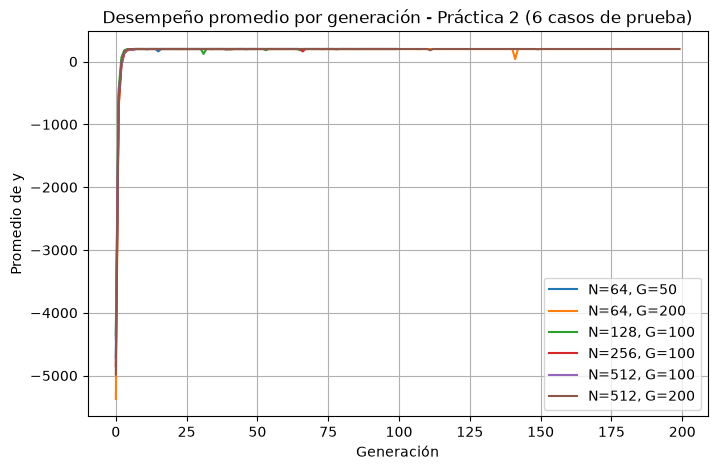

In [13]:
# Graficas de desempeño de los 6 casos
plt.figure(figsize=(8, 5))
for caso in range(len(poblaciones_p2)):
    plt.plot(historial_p2[caso], label=f"N={poblaciones_p2[caso]}, G={generaciones_p2[caso]}")

plt.title("Desempeño promedio por generación - Práctica 2 (6 casos de prueba)")
plt.xlabel("Generación")
plt.ylabel("Promedio de y")
plt.legend()
plt.grid(True)
plt.show()


**Análisis de la población final (Práctica 2)**

El óptimo global es $x=41.125$, $y=200$.

| Caso | Población | Generaciones | x* | y* | Desv. estándar final | Tiempo (s) |
|---|---|---|---|---|---|---|
| 1 | 64  | 50  | 41.0138 | 199.9876 | 0.0000 | 0.0586 |
| 2 | 64  | 200 | 40.5255 | 199.6406 | 0.0000 | 0.2559 |
| 3 | 128 | 100 | 41.1298 | 200.0000 | 0.0000 | 0.3196 |
| 4 | 256 | 100 | 41.4655 | 199.8841 | 0.0011 | 0.4860 |
| 5 | 512 | 100 | 40.9650 | 199.9744 | 0.0000 | 0.8739 |
| 6 | 512 | 200 | 41.1115 | 199.9998 | 2.2076 | 1.7585 |

- **Caso 1 vs. Caso 2 (misma población, N=64):** con 4 veces más generaciones (200 en lugar de 50), el resultado **empeora** ($y=199.64$ frente a $y=199.99$) y en ambos casos la desviación estándar final es 0. Esto es evidencia clara de **estancamiento en un óptimo local**: con solo 64 individuos en un espacio de más de 32,000 combinaciones posibles, la población se homogeneiza muy rápido; una vez que esto ocurre, cruzar padres idénticos ya no genera variación y solo queda la mutación (10% de probabilidad, un bit por generación) para escapar, lo cual es demasiado lento y puede dejar a la población atrapada en un punto mediocre.
- **Casos 3, 4 y 5 (N=128 a 512):** con poblaciones más grandes el algoritmo alcanza resultados muy cercanos al **óptimo global** ($y$ entre 199.88 y 200.00), confirmando que una mayor población preserva diversidad genética por más tiempo y reduce el riesgo de estancamiento.
- **Caso 6 (N=512, G=200):** es el único caso que conserva diversidad en la población final (desviación estándar = 2.2076) y, aun así, obtiene el mejor resultado de todos ($y=199.9998$, prácticamente el óptimo global): con una población suficientemente grande, más generaciones sí ayudan a refinar la solución sin caer en estancamiento.
- **Tiempo de ejecución:** crece de forma aproximadamente proporcional al producto población × generaciones (de 0.0586 s a 1.7585 s), lo cual es consistente con el costo por generación, que depende linealmente del tamaño de la población.
- **Costo computacional vs. beneficio:** un mayor tamaño de población y número de generaciones no siempre se traduce en un mejor resultado. El Caso 3 (N=128, G=100) ya prácticamente alcanza el óptimo global ($y=200.0000$) en 0.3196 s, mientras que el Caso 6 (N=512, G=200) obtiene un resultado casi idéntico ($y=199.9998$) pero tarda 1.7585 s (cerca de 5.5 veces más); incluso el Caso 2 (N=64, G=200), a pesar de usar más generaciones que el Caso 1, obtiene un resultado peor. Esto confirma que invertir más recursos computacionales no garantiza una mejor solución.

**Conclusión de esta prueba:** en la Práctica 2 el riesgo de estancamiento en óptimos locales es mayor que en la Práctica 1, porque el espacio de búsqueda es mucho más grande. Poblaciones pequeñas (N=64) pueden "encerrarse" en una solución subóptima incluso con muchas generaciones, mientras que poblaciones grandes (N≥128) logran acercarse consistentemente al óptimo global. Aun así, más allá de cierto punto (como en el Caso 6) aumentar todavía más la población o las generaciones implica un costo computacional mucho mayor sin una mejora significativa en el resultado, por lo que no siempre conviene usar los parámetros más grandes posibles.



## Conclusiones personales:

- **Conclusiones Esmer:** En esta práctica aprendí que los algoritmos genéticos sirven para encontrar buenas soluciones a problemas de optimización mediante procesos como selección, cruzamiento y mutación. Me di cuenta de que el tamaño de la población y el número de generaciones influyen en los resultados y que no siempre se llega al óptimo global, ya que el algoritmo puede estancarse en una solución local. También entendí mejor las diferencias entre los tipos de cruzamiento y cómo pueden afectar la evolución de la población. En general, la práctica me ayudó a comprender de forma más clara cómo los algoritmos genéticos pueden utilizarse para resolver problemas de manera eficiente.

- **Conclusiones Fany:**

- **Conclusiones Fer:** Me pareció muy útil el hacer este reporte ya que asi me quedó aún más claro lo que pudimos ver en clases. Asi mismo los algoritmos genéticos se me hizo un tema super enriquecedor e interesante, pues estamos combinando y aplicando temas biologicos en formas de optimizar. Finalmente, este trabajo me hizo pensar en que este tipo de algoritmos se puede aplicar a problemas mucho más complejos de la vida real, donde no siempre hay una fórmula que te diga directamente cuál es la mejor solución.

- **Conclusiones Dayanni:** Es interesante entender cómo surgen estos modelos heurísticos que parten de un fenómeno observado en la biología como la teoría de Darwin, que se puede aplicar como un método de optimización. Me hace preguntarme la cantidad inmensa de fenómenos de la naturaleza que podemos usar de manera aritifical para replicar con algoritmos y conseguir un resultado. 